# Adaptive Sequencer Selection

## Equilibrium, learning, and the decentralization–efficiency trade-off

Five self-interested sequencers repeatedly compete for transaction-ordering rights. Early rewards can be reinvested in stake and infrastructure, so an early lead may become a persistent advantage. This notebook asks:

> **Can a history-dependent anti-concentration rule reduce persistent sequencing dominance while preserving most system welfare?**

The notebook separates two claims that are often confused:

1. A small, finite two-period game can be checked using Nash and Selten-style continuation incentives.
2. A five-agent learning simulation can produce stable **equilibrium-like** behavior, but convergence alone is not a proof of subgame-perfect equilibrium.

The default experiment is fully reproducible, runs on a CPU, and requires no API key.

## Learning objectives

By the end of the notebook, you should be able to:

- construct and verify pure-strategy Nash equilibria using unilateral deviations;
- explain why a repeated, history-dependent sequencer game is closer to Selten's dynamic framework than to a one-shot matrix game;
- simulate five independent Q-learning sequencers under fixed and adaptive selection rules;
- measure concentration using reward shares, win shares, HHI, and normalized HHI;
- measure the welfare cost of decentralization without treating protocol rewards as social welfare;
- distinguish a learned steady pattern from a formally verified equilibrium.

In [ ]:
# Match the reference notebook's game-tree stack.
# PyGambit may compile from source on the first Linux/Colab installation.
import sys
import os
import shutil
import subprocess
from importlib.metadata import version, PackageNotFoundError

required = {"pygambit": "16.7.0", "ipywidgets": "8.1.7"}
for package, wanted in required.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    if installed != wanted:
        build_env = os.environ.copy()
        if package == "pygambit" and sys.platform.startswith("linux"):
            for setting, executable in {
                "CC": "gcc", "CXX": "g++", "AR": "ar", "RANLIB": "ranlib"
            }.items():
                found = shutil.which(executable)
                if found is None:
                    raise RuntimeError(
                        "A C++ build tool is missing. Use Colab or install C++ build tools."
                    )
                build_env[setting] = found
            build_env["LDSHARED"] = build_env["CXX"] + " -shared"
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", f"{package}=={wanted}"],
            env=build_env,
        )

print("Python", sys.version.split()[0])
for package in required:
    print(package, version(package))

In [ ]:
# Core dependencies are preinstalled in Google Colab and standard Jupyter environments.
from dataclasses import dataclass, replace
from itertools import product
from typing import Dict, Iterable, List, Tuple
import warnings

import pygambit as gb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from pathlib import Path

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)
EXPORT = Path("game_exports")
EXPORT.mkdir(exist_ok=True)
SEED = 206
print("Environment ready. PyGambit", version("pygambit"), "· NumPy", np.__version__)

## 1. Model primitives

Sequencer $i$ chooses an action $a_i\in\{L,M,A\}$: low, medium, or aggressive participation. Its effective competitive score is

\[
z_{i,t}=\theta_i x_{i,t}^{\gamma}e(a_{i,t}),
\]

where $\theta_i$ is operational productivity, $x_{i,t}$ is accumulated infrastructure or stake, $\gamma$ controls increasing returns, and $e(a)$ is participation intensity.

Under the fixed rule,

\[
P^{F}_{i,t}=\frac{z_{i,t}}{\sum_jz_{j,t}}.
\]

Let $q_{i,t}$ be agent $i$'s cumulative reward share. Under the adaptive rule,

\[
\widetilde z_{i,t}=z_{i,t}
\exp\!\left[-\lambda\max(0,q_{i,t}-\tau)\right],
\qquad
P^{A}_{i,t}=\frac{\widetilde z_{i,t}}{\sum_j\widetilde z_{j,t}}.
\]

Here $\lambda\ge 0$ is the anti-concentration strength and $\tau$ is a tolerance threshold. Setting $\lambda=0$ reproduces the fixed rule exactly.

In [3]:
ACTIONS = ("Low", "Medium", "Aggressive")
INTENSITY = np.array([0.72, 1.00, 1.52], dtype=float)
COST = np.array([0.020, 0.075, 0.190], dtype=float)
SERVICE = np.array([0.90, 1.00, 1.07], dtype=float)

def selection_probabilities(stakes, abilities, actions, gamma=1.30,
                            reward_shares=None, anti_strength=0.0,
                            threshold=0.25):
    # Return normalized sequencing probabilities for one round.
    stakes = np.asarray(stakes, dtype=float)
    abilities = np.asarray(abilities, dtype=float)
    actions = np.asarray(actions, dtype=int)
    scores = abilities * np.power(stakes, gamma) * INTENSITY[actions]
    if reward_shares is not None and anti_strength > 0:
        excess = np.maximum(np.asarray(reward_shares) - threshold, 0.0)
        scores = scores * np.exp(-anti_strength * excess)
    if np.any(scores < 0) or not np.isfinite(scores).all() or scores.sum() <= 0:
        raise ValueError("Selection scores must be finite, nonnegative, and nonzero.")
    return scores / scores.sum()

def expected_stage_payoffs(stakes, abilities, actions, prize=1.0,
                           gamma=1.30, reward_shares=None,
                           anti_strength=0.0, threshold=0.25):
    probs = selection_probabilities(
        stakes, abilities, actions, gamma, reward_shares,
        anti_strength, threshold
    )
    return probs * prize - COST[np.asarray(actions, dtype=int)]

## 2. Framing the research question as a game

The research question can be represented at three related levels. The matrix game is a one-round reduced-form benchmark; the extensive-form tree adds timing and continuation incentives; the full application is a stochastic repeated game whose state changes after every sequencing contest.

| Game component | Sequencer interpretation |
|---|---|
| Players | Five self-interested sequencers, $N=\{1,\ldots,5\}$ |
| Actions | $A_i=\{L,M,A\}$: low, medium, or aggressive participation |
| Public information | Past winners, cumulative rewards, stakes, and the current mechanism rule |
| One-round payoff | Expected sequencing reward and MEV minus participation cost |
| State | $s_t=(x_{1,t},\ldots,x_{5,t},q_{1,t},\ldots,q_{5,t})$ |
| Transition | The winner receives a reward and reinvests a fraction in future capacity |
| Fixed mechanism | Selection probability depends on current competitive score |
| Adaptive mechanism | Selection probability also decreases when cumulative reward share exceeds a threshold |
| Stage-game solution | Nash equilibrium and unilateral-deviation regret |
| Dynamic benchmark | Subgame-perfect continuation behavior in a finite two-period reduction |
| Full-model object | Learning outcomes in a five-player stochastic/Markov game |

### Matrix-game representation

Holding the state $s_t$ fixed gives a finite normal-form game

\[
G(s_t)=\langle N,(A_i)_{i\in N},(u_i)_{i\in N}\rangle,
\qquad
u_i(a_i,a_{-i}\mid s_t)=P_i(a_i,a_{-i}\mid s_t)B-c(a_i).
\]

With five players and three actions there are $3^5=243$ action profiles in the stage game. For a readable payoff matrix, Section 3 uses a symmetric two-player reduction while preserving the same probability and payoff equations. That reduction is an analytical benchmark—not a replacement for the five-player simulation.

### Dynamic game-tree representation

The dynamic version adds a public state transition. Round-1 actions affect the winner, the winner's capacity, the next reward-share vector, the rule applied in the continuation game, and therefore future incentives. Because each round contains simultaneous choices, the second mover's decision nodes belong to one information set: it does not observe the other agent's current action before choosing its own.

The figure below is generated from an **actual PyGambit extensive-form game object**, using the same construction-and-display workflow as the reference notebook. Player 2's three nodes are linked in one information set, and each action profile leads to a Nature node whose probabilities reproduce the stage-game selection rule. The displayed tree ends after one contest so it remains readable. A full two-period tree replaces every terminal node with another copy of the action-and-Nature structure; Section 4 computes those continuation values without drawing all 162 terminal histories.

The notebook also exports `game_exports/sequencer_stage_game.efg`, which can be opened and edited in the Gambit desktop application.

In [ ]:
def draw_tree(game, filename=None):
    # Draw the actual nodes, actions, chance probabilities, and information sets.
    positions, leaves, levels = {}, [], []

    def place(node, depth=0):
        children = list(node.children)
        if not children:
            x = len(leaves)
            leaves.append(node)
        else:
            x = np.mean([place(child, depth + 1) for child in children])
        positions[node] = (x, -depth)
        levels.append(depth)
        return x

    place(game.root)
    fig, ax = plt.subplots(figsize=(max(11, len(leaves) * 0.82), 6.1))
    colors = {"Sequencer 1": "#166B8F", "Sequencer 2": "#A75119"}

    for node, (x, y) in positions.items():
        children = list(node.children)
        if not children:
            payoffs = tuple(str(node.outcome[p]) for p in game.players)
            ax.text(x, y - 0.13, "(" + ", ".join(payoffs) + ")",
                    ha="center", fontsize=8)
            continue

        info = node.infoset
        is_chance = info.player == game.players.chance
        color = "#606974" if is_chance else colors.get(info.player.label, "#166B8F")
        ax.scatter([x], [y], s=75, c=color, zorder=4)
        node_label = info.label or info.player.label or "Nature"
        ax.text(x, y + 0.12, node_label, ha="center", fontsize=8.5)

        for action, child in zip(info.actions, children):
            cx, cy = positions[child]
            ax.plot([x, cx], [y, cy], color="#7A8793", linewidth=1.15)
            branch_label = action.label
            if is_chance:
                branch_label += f"\nP={float(action.prob):.2f}"
            ax.text((x + cx) / 2, (y + cy) / 2, branch_label,
                    ha="center", fontsize=7.5,
                    bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.2})

    for info in game.infosets:
        members = list(info.members)
        if len(members) > 1:
            xy = sorted([positions[node] for node in members])
            ax.plot([p[0] for p in xy], [p[1] for p in xy], "--",
                    color="#693F96", linewidth=2)

    ax.set_title(
        game.title + "\nDashed line = nodes the acting player cannot distinguish",
        fontsize=11, pad=20,
    )
    ax.set_xlim(-0.7, len(leaves) - 0.3)
    ax.set_ylim(-max(levels) - 0.55, 0.65)
    ax.axis("off")
    fig.tight_layout()
    if filename:
        fig.savefig(filename, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def make_sequencer_stage_tree():
    # Build the matrix game's equivalent extensive form in PyGambit.
    game = gb.Game.new_tree(
        players=["Sequencer 1", "Sequencer 2"],
        title="Sequencer stage game: simultaneous participation and stochastic selection",
    )
    game.append_move(game.root, "Sequencer 1", list(ACTIONS))
    p1_nodes = list(game.root.children)

    # One information set across all three nodes makes round-1 choice simultaneous.
    game.append_move(p1_nodes, "Sequencer 2", list(ACTIONS))
    p1_nodes[0].infoset.label = "Sequencer 2 · I1"

    rational_intensity = [gb.Rational("0.72"), gb.Rational("1.00"), gb.Rational("1.52")]
    rational_cost = [gb.Rational("0.020"), gb.Rational("0.075"), gb.Rational("0.190")]

    for a0, p1_node in enumerate(p1_nodes):
        for a1, joint_node in enumerate(p1_node.children):
            game.append_move(joint_node, game.players.chance, ["S1 wins", "S2 wins"])
            joint_node.infoset.label = f"Nature: {ACTIONS[a0]}/{ACTIONS[a1]}"
            denominator = rational_intensity[a0] + rational_intensity[a1]
            p0 = rational_intensity[a0] / denominator
            game.set_chance_probs(joint_node.infoset, [p0, 1 - p0])

            leaves = list(joint_node.children)
            payoff_vectors = [
                [1 - rational_cost[a0], -rational_cost[a1]],
                [-rational_cost[a0], 1 - rational_cost[a1]],
            ]
            labels = [
                f"{ACTIONS[a0]}/{ACTIONS[a1]}: S1 wins",
                f"{ACTIONS[a0]}/{ACTIONS[a1]}: S2 wins",
            ]
            for leaf, label, payoffs in zip(leaves, labels, payoff_vectors):
                game.set_outcome(
                    leaf, game.add_outcome(label=label, payoffs=payoffs)
                )
    return game


sequencer_stage_tree = make_sequencer_stage_tree()
draw_tree(sequencer_stage_tree)
sequencer_stage_tree.to_efg(EXPORT / "sequencer_stage_game.efg")
print("Exported:", EXPORT / "sequencer_stage_game.efg")

## 3. A one-round Nash benchmark

Start with two symmetric sequencers and enumerate all $3\times3$ action profiles. A profile is a pure Nash equilibrium if neither player has a profitable unilateral deviation. The code reports maximum deviation gain (regret), which equals zero at an exact pure equilibrium.

In [5]:
def two_player_payoff_matrices(stakes=(1.0, 1.0), abilities=(1.0, 1.0),
                              prize=1.0, gamma=1.30,
                              reward_shares=None, anti_strength=0.0,
                              threshold=0.50):
    u0 = np.zeros((3, 3))
    u1 = np.zeros((3, 3))
    for a0, a1 in product(range(3), repeat=2):
        payoffs = expected_stage_payoffs(
            stakes, abilities, (a0, a1), prize, gamma,
            reward_shares, anti_strength, threshold
        )
        u0[a0, a1], u1[a0, a1] = payoffs
    return u0, u1

def pure_nash_profiles(u0, u1, tol=1e-10):
    records = []
    for a0, a1 in product(range(u0.shape[0]), range(u0.shape[1])):
        gain0 = float(u0[:, a1].max() - u0[a0, a1])
        gain1 = float(u1[a0, :].max() - u1[a0, a1])
        regret = max(gain0, gain1)
        if regret <= tol:
            records.append({
                "Player 1": ACTIONS[a0], "Player 2": ACTIONS[a1],
                "Payoff 1": u0[a0, a1], "Payoff 2": u1[a0, a1],
                "Max deviation gain": regret,
            })
    return pd.DataFrame(records)

u0, u1 = two_player_payoff_matrices()
payoff_table = pd.DataFrame(
    [[f"({u0[i,j]:.3f}, {u1[i,j]:.3f})" for j in range(3)] for i in range(3)],
    index=pd.Index(ACTIONS, name="Player 1"),
    columns=pd.Index(ACTIONS, name="Player 2"),
)
display(payoff_table)
display(Markdown("**Pure-strategy Nash profiles**"))
display(pure_nash_profiles(u0, u1))

Player 2,Low,Medium,Aggressive
Player 1,,,
Low,"(0.480, 0.480)","(0.399, 0.506)","(0.301, 0.489)"
Medium,"(0.506, 0.399)","(0.425, 0.425)","(0.322, 0.413)"
Aggressive,"(0.489, 0.301)","(0.413, 0.322)","(0.310, 0.310)"


**Pure-strategy Nash profiles**

,Player 1,Player 2,Payoff 1,Payoff 2,Max deviation gain
0,Medium,Medium,0.425,0.425,0.0


### Interpretation

This one-shot benchmark answers a Nash question: holding the other sequencer's action fixed, would either player gain by deviating alone? It does **not** yet model reinvestment, accumulated advantage, or credible continuation behavior. Those require a dynamic game.

## 4. A two-period Selten benchmark

The full five-agent repeated game is too large to display as an explicit finite tree. We therefore use a tractable two-player, two-period benchmark:

1. both agents choose an action in period 1;
2. the period-1 winner receives an infrastructure boost;
3. period-2 actions are chosen after the winner is observed;
4. period-2 behavior is solved separately after every possible history;
5. period-1 incentives include discounted continuation payoffs.

This is the Selten-style discipline: a proposed strategy must remain optimal in every continuation game, including histories that may not occur on the equilibrium path.

In [6]:
def continuation_game(winner, adaptive=False, boost=0.65,
                      anti_strength=5.0, discount=0.92):
    stakes = np.ones(2)
    stakes[winner] += boost
    shares = np.zeros(2)
    shares[winner] = 1.0
    u0, u1 = two_player_payoff_matrices(
        stakes=stakes,
        abilities=(1.0, 1.0),
        reward_shares=shares if adaptive else None,
        anti_strength=anti_strength if adaptive else 0.0,
        threshold=0.50,
    )
    eq = pure_nash_profiles(u0, u1)
    if eq.empty:
        raise RuntimeError("The default continuation game should have a pure equilibrium.")
    # A transparent equilibrium-selection rule for this classroom benchmark:
    # choose the pure equilibrium with the largest joint continuation payoff.
    eq = eq.assign(joint=eq["Payoff 1"] + eq["Payoff 2"])
    chosen = eq.sort_values(["joint", "Player 1", "Player 2"], ascending=False).iloc[0]
    a0 = ACTIONS.index(chosen["Player 1"])
    a1 = ACTIONS.index(chosen["Player 2"])
    return {
        "winner": winner + 1,
        "actions": (a0, a1),
        "payoffs": np.array([chosen["Payoff 1"], chosen["Payoff 2"]]),
        "all_equilibria": eq.drop(columns="joint"),
        "stakes": stakes,
    }

def selten_benchmark(adaptive=False, boost=0.65, anti_strength=5.0,
                     discount=0.92):
    cont = {
        w: continuation_game(w, adaptive, boost, anti_strength, discount)
        for w in (0, 1)
    }
    first_u0 = np.zeros((3, 3))
    first_u1 = np.zeros((3, 3))
    for a0, a1 in product(range(3), repeat=2):
        probs = selection_probabilities(
            np.ones(2), np.ones(2), (a0, a1), gamma=1.30
        )
        immediate = probs - COST[[a0, a1]]
        expected_cont = probs[0] * cont[0]["payoffs"] + probs[1] * cont[1]["payoffs"]
        total = immediate + discount * expected_cont
        first_u0[a0, a1], first_u1[a0, a1] = total
    first_eq = pure_nash_profiles(first_u0, first_u1)
    return cont, first_u0, first_u1, first_eq

selten_rows = []
selten_objects = {}
for label, adaptive in [("Fixed", False), ("Adaptive", True)]:
    cont, su0, su1, first_eq = selten_benchmark(adaptive=adaptive)
    selten_objects[label] = (cont, su0, su1, first_eq)
    for winner in (0, 1):
        c = cont[winner]
        selten_rows.append({
            "Mechanism": label,
            "Round-1 winner": f"Player {winner + 1}",
            "Round-2 stake": tuple(np.round(c["stakes"], 2)),
            "Selected continuation equilibrium":
                f"({ACTIONS[c['actions'][0]]}, {ACTIONS[c['actions'][1]]})",
            "Continuation payoffs": tuple(np.round(c["payoffs"], 3)),
        })

display(pd.DataFrame(selten_rows))
for label in ("Fixed", "Adaptive"):
    display(Markdown(f"**{label} mechanism: period-1 equilibrium anticipating continuation play**"))
    display(selten_objects[label][3])

,Mechanism,Round-1 winner,Round-2 stake,Selected continuation equilibrium,Continuation payoffs
0,Fixed,Player 1,"(1.65, 1.0)","(Medium, Medium)","(0.582, 0.268)"
1,Fixed,Player 2,"(1.0, 1.65)","(Medium, Medium)","(0.268, 0.582)"
2,Adaptive,Player 1,"(1.65, 1.0)","(Low, Low)","(0.116, 0.844)"
3,Adaptive,Player 2,"(1.0, 1.65)","(Low, Low)","(0.844, 0.116)"


**Fixed mechanism: period-1 equilibrium anticipating continuation play**

,Player 1,Player 2,Payoff 1,Payoff 2,Max deviation gain
0,Aggressive,Aggressive,0.701,0.701,0.0


**Adaptive mechanism: period-1 equilibrium anticipating continuation play**

,Player 1,Player 2,Payoff 1,Payoff 2,Max deviation gain
0,Low,Low,0.9216,0.9216,0.0


### What the two-period model establishes—and what it does not

The calculation verifies continuation optimality in a deliberately small finite model. Its equilibrium-selection rule is explicit because some continuation games can have multiple pure equilibria. It is a theoretical benchmark, not a claim that the full five-agent learning environment has the same equilibrium.

## 5. Five learning sequencers

We now return to the application scenario. Each agent uses independent tabular Q-learning. Its state records:

- whether its own cumulative reward share is low, ordinary, or dominant;
- whether system concentration is below or above a normalized-HHI threshold.

After each round, the winner reinvests part of the gross reward. The environment is non-stationary from each learner's perspective because all five policies change simultaneously.

In [7]:
@dataclass(frozen=True)
class SequencerConfig:
    n_agents: int = 5
    rounds: int = 1_500
    gamma: float = 1.35
    reinvestment_rate: float = 0.42
    base_prize: float = 1.0
    mev_strength: float = 0.18
    learning_rate: float = 0.10
    discount: float = 0.92
    epsilon_start: float = 0.24
    epsilon_end: float = 0.025
    anti_strength: float = 5.0
    concentration_threshold: float = 0.25
    high_hhi_threshold: float = 0.18
    abilities: Tuple[float, ...] = (1.08, 1.04, 1.00, 0.96, 0.92)

    def validate(self):
        if self.n_agents != len(self.abilities):
            raise ValueError("n_agents must equal the number of ability values.")
        if self.rounds < 2:
            raise ValueError("rounds must be at least 2.")
        if not 0 <= self.epsilon_end <= self.epsilon_start <= 1:
            raise ValueError("Require 0 <= epsilon_end <= epsilon_start <= 1.")
        if not 0 <= self.reinvestment_rate <= 1:
            raise ValueError("reinvestment_rate must be in [0, 1].")
        return self

def normalized_hhi(shares):
    shares = np.asarray(shares, dtype=float)
    n = len(shares)
    return float((np.square(shares).sum() - 1/n) / (1 - 1/n))

def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    if x.sum() <= 0:
        return 0.0
    n = len(x)
    return float((2 * np.dot(np.arange(1, n + 1), x) / (n * x.sum())) - (n + 1) / n)

def state_index(own_share, norm_hhi):
    own_bin = 0 if own_share < 0.16 else (1 if own_share <= 0.28 else 2)
    hhi_bin = int(norm_hhi >= 0.18)
    return own_bin, hhi_bin

In [8]:
def simulate(config=SequencerConfig(), mechanism="fixed", seed=SEED,
             track=True):
    config.validate()
    if mechanism not in {"fixed", "adaptive"}:
        raise ValueError("mechanism must be 'fixed' or 'adaptive'.")

    rng = np.random.default_rng(seed)
    n = config.n_agents
    abilities = np.asarray(config.abilities, dtype=float)
    stakes = np.ones(n)
    rewards = np.zeros(n)
    wins = np.zeros(n, dtype=int)
    q_values = np.zeros((n, 3, 2, 3), dtype=float)

    records = []
    action_counts = np.zeros((n, 3), dtype=int)

    for t in range(config.rounds):
        reward_shares = ((rewards + 1e-9) / (rewards.sum() + n * 1e-9))
        nhhi = normalized_hhi(reward_shares)
        states = [state_index(reward_shares[i], nhhi) for i in range(n)]
        epsilon = config.epsilon_end + (
            config.epsilon_start - config.epsilon_end
        ) * (1 - t / (config.rounds - 1))

        actions = np.empty(n, dtype=int)
        for i, (own_bin, hhi_bin) in enumerate(states):
            if rng.random() < epsilon:
                actions[i] = rng.integers(0, 3)
            else:
                values = q_values[i, own_bin, hhi_bin]
                best = np.flatnonzero(np.isclose(values, values.max()))
                actions[i] = rng.choice(best)
            action_counts[i, actions[i]] += 1

        anti = config.anti_strength if mechanism == "adaptive" else 0.0
        probs = selection_probabilities(
            stakes, abilities, actions, config.gamma,
            reward_shares, anti, config.concentration_threshold
        )
        winner = int(rng.choice(n, p=probs))

        gross_prize = config.base_prize * (
            1 + config.mev_strength * (INTENSITY[actions[winner]] - 1)
        )
        utilities = -COST[actions].copy()
        utilities[winner] += gross_prize
        welfare = abilities[winner] * SERVICE[actions[winner]] - COST[actions].sum()

        wins[winner] += 1
        rewards[winner] += gross_prize
        stakes[winner] += config.reinvestment_rate * gross_prize

        next_shares = (rewards + 1e-9) / (rewards.sum() + n * 1e-9)
        next_nhhi = normalized_hhi(next_shares)
        for i, (own_bin, hhi_bin) in enumerate(states):
            next_own, next_hhi_bin = state_index(next_shares[i], next_nhhi)
            old = q_values[i, own_bin, hhi_bin, actions[i]]
            target = utilities[i] + config.discount * q_values[i, next_own, next_hhi_bin].max()
            q_values[i, own_bin, hhi_bin, actions[i]] = (
                (1 - config.learning_rate) * old + config.learning_rate * target
            )

        if track:
            records.append({
                "round": t + 1,
                "winner": winner,
                "welfare": welfare,
                "norm_hhi": next_nhhi,
                "gini_rewards": gini(rewards),
                "max_reward_share": next_shares.max(),
                **{f"reward_share_{i+1}": next_shares[i] for i in range(n)},
                **{f"stake_{i+1}": stakes[i] for i in range(n)},
            })

    final_reward_shares = (rewards + 1e-9) / (rewards.sum() + n * 1e-9)
    final_win_shares = wins / wins.sum()
    history = pd.DataFrame(records) if track else None
    return {
        "mechanism": mechanism,
        "seed": seed,
        "history": history,
        "stakes": stakes,
        "rewards": rewards,
        "reward_shares": final_reward_shares,
        "wins": wins,
        "win_shares": final_win_shares,
        "q_values": q_values,
        "action_frequencies": action_counts / config.rounds,
        "mean_welfare": float(history["welfare"].mean()) if track else np.nan,
        "final_norm_hhi": normalized_hhi(final_reward_shares),
    }

## 6. Reproducibility and correctness checks

These tests encode properties that must hold independently of the expected research finding. In particular, when $\lambda=0$, the adaptive implementation must be identical to the fixed mechanism under the same random seed.

In [ ]:
test_cfg = replace(SequencerConfig(), rounds=120)

# PyGambit representation checks: three P1 actions and one three-node
# information set for P2's simultaneous choice.
assert len(list(sequencer_stage_tree.root.children)) == 3
p2_information_set = next(
    info for info in sequencer_stage_tree.infosets
    if info.label == "Sequencer 2 · I1"
)
assert len(list(p2_information_set.members)) == 3

# Probability invariants
test_p = selection_probabilities(
    np.ones(5), np.ones(5), np.array([0, 1, 2, 1, 0])
)
assert np.isclose(test_p.sum(), 1.0) and np.all(test_p >= 0)

# Simulation accounting invariants
test_run = simulate(test_cfg, "adaptive", seed=7)
assert test_run["wins"].sum() == test_cfg.rounds
assert np.isclose(test_run["reward_shares"].sum(), 1.0)
assert np.isclose(test_run["win_shares"].sum(), 1.0)

# Nested-mechanism check: adaptive(lambda=0) == fixed
zero_cfg = replace(test_cfg, anti_strength=0.0)
fixed_zero = simulate(zero_cfg, "fixed", seed=11)
adaptive_zero = simulate(zero_cfg, "adaptive", seed=11)
assert np.array_equal(fixed_zero["wins"], adaptive_zero["wins"])
assert np.allclose(fixed_zero["rewards"], adaptive_zero["rewards"])
assert np.allclose(
    fixed_zero["history"]["norm_hhi"],
    adaptive_zero["history"]["norm_hhi"]
)

# Exact pure equilibria have zero unilateral-deviation gain.
ne = pure_nash_profiles(u0, u1)
assert not ne.empty and np.all(ne["Max deviation gain"] <= 1e-10)

print("All model, accounting, nesting, and equilibrium checks passed.")

## 7. Baseline experiment across multiple seeds

A single stochastic run can be misleading. We therefore compare the two mechanisms using the same set of seeds and report paired averages. The fixed-mechanism mean welfare is the reference for efficiency retention.

In [10]:
def run_experiment(config, seeds=range(20)):
    rows = []
    saved = {}
    for mechanism in ("fixed", "adaptive"):
        for seed in seeds:
            result = simulate(config, mechanism, seed=int(seed), track=True)
            tail = result["history"].tail(max(100, config.rounds // 5))
            rows.append({
                "mechanism": mechanism.title(),
                "seed": int(seed),
                "final normalized HHI": result["final_norm_hhi"],
                "tail normalized HHI": tail["norm_hhi"].mean(),
                "mean welfare": result["mean_welfare"],
                "tail welfare": tail["welfare"].mean(),
                "largest reward share": result["reward_shares"].max(),
                "largest win share": result["win_shares"].max(),
            })
            if seed == list(seeds)[0]:
                saved[mechanism] = result
    return pd.DataFrame(rows), saved

baseline_config = SequencerConfig()
experiment, example_runs = run_experiment(baseline_config, seeds=range(20))

summary = experiment.groupby("mechanism").agg(
    seeds=("seed", "count"),
    mean_final_hhi=("final normalized HHI", "mean"),
    sd_final_hhi=("final normalized HHI", "std"),
    mean_welfare=("mean welfare", "mean"),
    sd_welfare=("mean welfare", "std"),
    mean_largest_reward_share=("largest reward share", "mean"),
    mean_largest_win_share=("largest win share", "mean"),
)
fixed_welfare = summary.loc["Fixed", "mean_welfare"]
summary["efficiency retention vs fixed"] = summary["mean_welfare"] / fixed_welfare
display(summary)

,seeds,mean_final_hhi,sd_final_hhi,mean_welfare,sd_welfare,mean_largest_reward_share,mean_largest_win_share,efficiency retention vs fixed
mechanism,,,,,,,,
Adaptive,20,0.1101,0.0305,0.6428,0.0271,0.3506,0.3431,0.9059
Fixed,20,0.5851,0.2855,0.7096,0.0518,0.7632,0.7608,1.0000


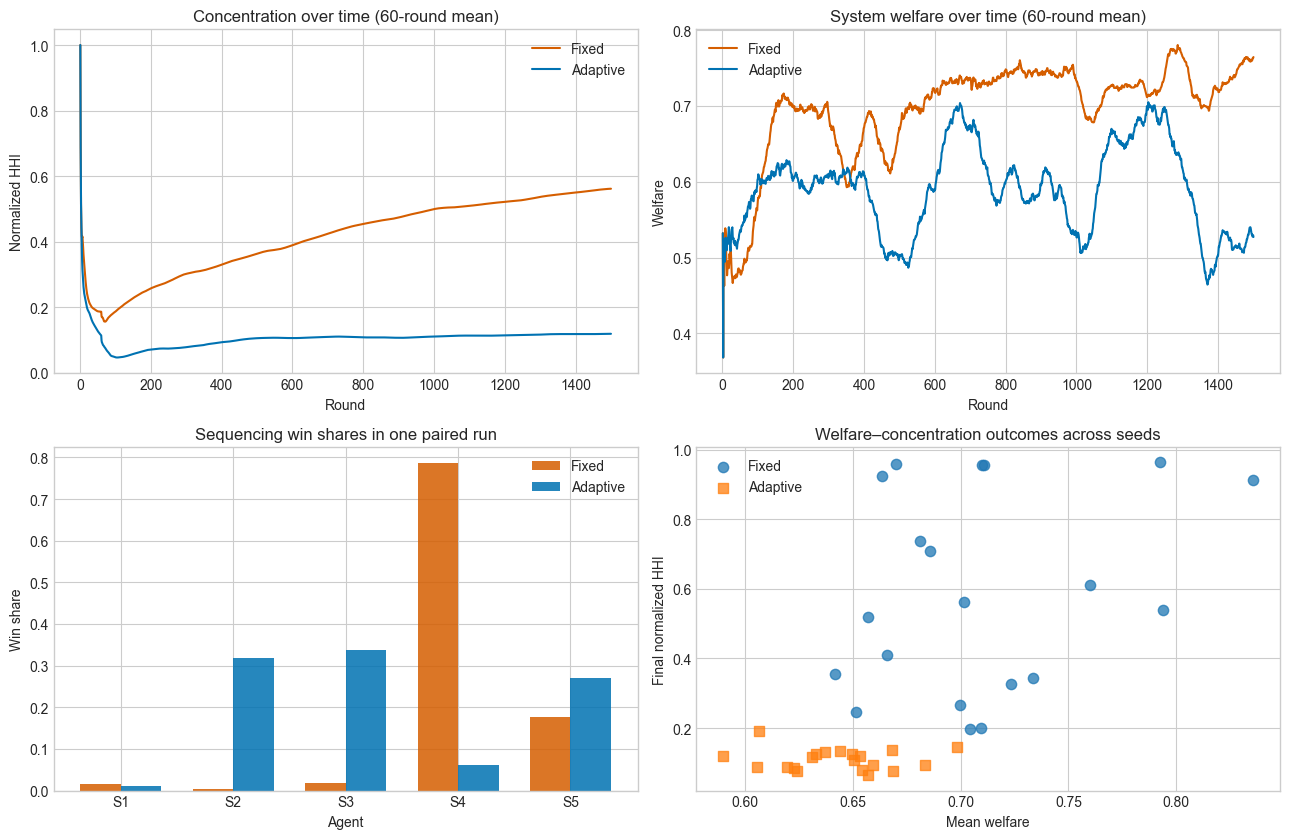

In [11]:
def plot_comparison(example_runs, experiment):
    colors = {"fixed": "#D55E00", "adaptive": "#0072B2"}
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

    for mechanism, result in example_runs.items():
        hist = result["history"]
        smooth = hist[["norm_hhi", "welfare"]].rolling(60, min_periods=1).mean()
        axes[0, 0].plot(hist["round"], smooth["norm_hhi"],
                        label=mechanism.title(), color=colors[mechanism])
        axes[0, 1].plot(hist["round"], smooth["welfare"],
                        label=mechanism.title(), color=colors[mechanism])

    axes[0, 0].set(title="Concentration over time (60-round mean)",
                   xlabel="Round", ylabel="Normalized HHI")
    axes[0, 1].set(title="System welfare over time (60-round mean)",
                   xlabel="Round", ylabel="Welfare")
    axes[0, 0].legend(); axes[0, 1].legend()

    positions = np.arange(5)
    width = 0.36
    for k, mechanism in enumerate(("fixed", "adaptive")):
        axes[1, 0].bar(
            positions + (k - 0.5) * width,
            example_runs[mechanism]["win_shares"],
            width=width, label=mechanism.title(), color=colors[mechanism], alpha=0.85
        )
    axes[1, 0].set(title="Sequencing win shares in one paired run",
                   xlabel="Agent", ylabel="Win share",
                   xticks=positions, xticklabels=[f"S{i+1}" for i in positions])
    axes[1, 0].legend()

    for mechanism, marker in [("Fixed", "o"), ("Adaptive", "s")]:
        part = experiment[experiment["mechanism"] == mechanism]
        axes[1, 1].scatter(
            part["mean welfare"], part["final normalized HHI"],
            label=mechanism, marker=marker, s=55, alpha=0.75
        )
    axes[1, 1].set(title="Welfare–concentration outcomes across seeds",
                   xlabel="Mean welfare", ylabel="Final normalized HHI")
    axes[1, 1].legend()
    fig.tight_layout()
    plt.show()

plot_comparison(example_runs, experiment)

In [12]:
def paired_effects_table(experiment):
    wide = experiment.pivot(index="seed", columns="mechanism")
    rows = []
    for metric in ["final normalized HHI", "mean welfare", "largest reward share"]:
        diff = wide[metric]["Adaptive"] - wide[metric]["Fixed"]
        rows.append({
            "Outcome": metric,
            "Adaptive − Fixed mean": diff.mean(),
            "Paired SE": diff.std(ddof=1) / np.sqrt(len(diff)),
            "Seeds favoring adaptive": (
                (diff < 0).sum() if "welfare" not in metric else (diff > 0).sum()
            ),
            "Number of seeds": len(diff),
        })
    return pd.DataFrame(rows)

display(Markdown("**Paired mechanism differences**"))
display(paired_effects_table(experiment))

**Paired mechanism differences**

,Outcome,Adaptive − Fixed mean,Paired SE,Seeds favoring adaptive,Number of seeds
0,final normalized HHI,-0.4750,0.0658,20,20
1,mean welfare,-0.0668,0.0119,0,20
2,largest reward share,-0.4126,0.0434,20,20


## 8. Equilibrium proximity diagnostic

A learned policy is not automatically a Nash equilibrium. As a transparent diagnostic, freeze the other agents' final greedy actions and calculate agent (i)'s best one-round deviation gain in the final state:

\[
\operatorname{regret}_i
=\max_{a_i'}u_i(a_i',a_{-i})-u_i(a_i,a_{-i}).
\]

This is only **stage-game regret at the terminal state**. It does not prove that a multi-period deviation would be unprofitable.

In [13]:
def terminal_stage_regret(result, config):
    shares = result["reward_shares"]
    nhhi = normalized_hhi(shares)
    q = result["q_values"]
    current_actions = []
    for i in range(config.n_agents):
        own_bin, hhi_bin = state_index(shares[i], nhhi)
        current_actions.append(int(np.argmax(q[i, own_bin, hhi_bin])))
    current_actions = np.asarray(current_actions)

    anti = config.anti_strength if result["mechanism"] == "adaptive" else 0.0
    base = expected_stage_payoffs(
        result["stakes"], config.abilities, current_actions,
        config.base_prize, config.gamma, shares, anti,
        config.concentration_threshold
    )
    regrets = []
    for i in range(config.n_agents):
        alternatives = []
        for action in range(3):
            deviated = current_actions.copy()
            deviated[i] = action
            payoff = expected_stage_payoffs(
                result["stakes"], config.abilities, deviated,
                config.base_prize, config.gamma, shares, anti,
                config.concentration_threshold
            )[i]
            alternatives.append(payoff)
        regrets.append(max(alternatives) - base[i])
    return pd.DataFrame({
        "Agent": [f"S{i+1}" for i in range(config.n_agents)],
        "Learned greedy action": [ACTIONS[a] for a in current_actions],
        "One-round deviation gain": regrets,
    })

for mechanism in ("fixed", "adaptive"):
    display(Markdown(f"**{mechanism.title()} mechanism, example seed**"))
    display(terminal_stage_regret(example_runs[mechanism], baseline_config))

**Fixed mechanism, example seed**

,Agent,Learned greedy action,One-round deviation gain
0,S1,Low,0.0000
1,S2,Low,0.0000
2,S3,Medium,0.0534
3,S4,Medium,0.0227
4,S5,Low,0.0000


**Adaptive mechanism, example seed**

,Agent,Learned greedy action,One-round deviation gain
0,S1,Low,0.0000
1,S2,Aggressive,0.0289
2,S3,Aggressive,0.0339
3,S4,Aggressive,0.1470
4,S5,Aggressive,0.0379


## 9. Interactive mechanism laboratory

Use the controls to run one paired fixed/adaptive experiment. Both mechanisms receive the same seed. The table emphasizes the two design objectives: lower concentration and high efficiency retention.

In [14]:
def interactive_comparison(rounds=1000, anti_strength=5.0, gamma=1.35,
                           reinvestment_rate=0.42, learning_rate=0.10,
                           seed=206):
    cfg = replace(
        SequencerConfig(), rounds=int(rounds),
        anti_strength=float(anti_strength), gamma=float(gamma),
        reinvestment_rate=float(reinvestment_rate),
        learning_rate=float(learning_rate)
    )
    fixed = simulate(cfg, "fixed", int(seed))
    adaptive = simulate(cfg, "adaptive", int(seed))
    rows = []
    for result in (fixed, adaptive):
        rows.append({
            "Mechanism": result["mechanism"].title(),
            "Final normalized HHI": result["final_norm_hhi"],
            "Mean welfare": result["mean_welfare"],
            "Largest reward share": result["reward_shares"].max(),
            "Largest win share": result["win_shares"].max(),
        })
    table = pd.DataFrame(rows).set_index("Mechanism")
    table["Efficiency retention"] = table["Mean welfare"] / table.loc["Fixed", "Mean welfare"]
    display(table)
    plot_comparison({"fixed": fixed, "adaptive": adaptive},
                    pd.DataFrame([
                        {"mechanism": "Fixed", "mean welfare": fixed["mean_welfare"],
                         "final normalized HHI": fixed["final_norm_hhi"]},
                        {"mechanism": "Adaptive", "mean welfare": adaptive["mean_welfare"],
                         "final normalized HHI": adaptive["final_norm_hhi"]},
                    ]))

if WIDGETS_AVAILABLE:
    controls = {
        "rounds": widgets.IntSlider(value=1000, min=300, max=3000, step=100,
                                     description="Rounds"),
        "anti_strength": widgets.FloatSlider(value=5.0, min=0, max=12, step=0.5,
                                              description="Anti λ"),
        "gamma": widgets.FloatSlider(value=1.35, min=0.7, max=2.0, step=0.05,
                                      description="Returns γ"),
        "reinvestment_rate": widgets.FloatSlider(value=0.42, min=0, max=0.8, step=0.02,
                                                  description="Reinvest ρ"),
        "learning_rate": widgets.FloatSlider(value=0.10, min=0.02, max=0.35, step=0.01,
                                              description="Learning η"),
        "seed": widgets.IntText(value=206, description="Seed"),
    }
    ui = widgets.VBox(list(controls.values()))
    output = widgets.interactive_output(interactive_comparison, controls)
    display(ui, output)
else:
    print("ipywidgets is unavailable; call interactive_comparison(...) directly.")

ipywidgets is unavailable; call interactive_comparison(...) directly.


## 10. Three perspectives

### Economics

The mechanism changes the mapping from individual effort and accumulated resources to future allocation. The design objective is not equal rewards at any cost; it is a lower-concentration outcome subject to an efficiency constraint. Productivity differences make that trade-off nontrivial.

### Computer science

The selection rule is an algorithm, and the sequencers are adaptive agents. Independent Q-learning provides a transparent baseline, while the invariants and nested-mechanism test guard against implementation mistakes. A stronger project could compare independent Q-learning with centralized-training/decentralized-execution methods.

### Behavioral science

Agents do not instantly solve the full dynamic game. They explore, reinforce actions that generated rewards, and respond to recent state categories. Early random wins can therefore shape later behavior and produce path dependence. Varying exploration and learning rates changes this behavioral channel.

### Selten connection

The two-period benchmark asks whether actions remain optimal after every history. The MARL simulation instead studies behavior generated by bounded, adaptive learners. Comparing the two highlights the difference between rational equilibrium prediction and a learning process that may or may not approach it.

## 11. Interpretation checklist

Before claiming that the adaptive rule succeeds, verify all four statements:

1. **Concentration:** adaptive normalized HHI and largest reward share are lower across seeds.
2. **Efficiency:** welfare retention remains close to one under a predeclared acceptable threshold.
3. **Robustness:** the result survives changes in $\gamma$, reinvestment, exploration, initial productivity, and random seed.
4. **Strategic stability:** learned policies have small deviation gains, or the paper explicitly describes them only as learning outcomes.

Do not select the anti-concentration parameter after looking only at the most favorable seed. A useful extension is to trace a welfare–concentration frontier over a predeclared grid of $\lambda$ values.

## 12. Limitations and extensions

- The two-period model is deliberately smaller than the five-agent application.
- Independent Q-learning faces a changing environment and has no general convergence guarantee here.
- The terminal regret diagnostic considers one-round deviations, not arbitrary dynamic deviations.
- Abilities and costs are common knowledge; adding privately known costs would move the model toward Harsanyi's Bayesian framework.
- Sybil attacks, collusion, delegation, latency, censorship resistance, and endogenous entry are outside the current model.
- The welfare function is illustrative and should be calibrated before making policy claims.

**Possible extensions**

1. sweep $\lambda$ to estimate the decentralization–efficiency frontier;
2. compare tabular learning with PPO or other MARL methods;
3. introduce private sequencer types and Bayesian beliefs;
4. allow collusion or stake delegation;
5. port the validated equations to a client-side JavaScript Hugging Face Static Space.

## 13. Suggested exercises

1. Set `anti_strength=0`. Why must the two mechanisms coincide under the same seed?
2. Increase `gamma`. Does stronger resource feedback increase concentration?
3. Set all ability values to 1. Does the welfare cost of decentralization change?
4. Change the aggressive-action cost. How does the one-shot Nash equilibrium change?
5. Replace the exponential penalty with a capped probability rule and rerun the invariants.
6. Add a hidden low-cost/high-cost type and explain which part of the analysis becomes Harsanyi-style.

## References

- Nash, J. F. (1950). *Equilibrium Points in N-Person Games*. Proceedings of the National Academy of Sciences, 36(1), 48–49.
- Selten, R. (1965). *Spieltheoretische Behandlung eines Oligopolmodells mit Nachfrageträgheit*. Zeitschrift für die gesamte Staatswissenschaft, 121, 301–324.
- Harsanyi, J. C. (1967–1968). *Games with Incomplete Information Played by “Bayesian” Players*. Management Science, 14.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Gambit Project. *Gambit: Software Tools for Game Theory*, PyGambit 16.7.0. https://www.gambit-project.org/

**Reproducibility note:** Default results use 20 paired seeds, 1,500 rounds per mechanism, deterministic NumPy random generators, and the parameter values printed in `SequencerConfig`.

**Software note:** The extensive-form game is constructed with PyGambit 16.7.0 and exported as Gambit `.efg`; the display helper reads that PyGambit object. Gambit/PyGambit is distributed under GPL-2.0-or-later.